In [5]:
# ============================================================
# CELLULE 1 : IMPORTS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

In [6]:
# ============================================================
# CELLULE 2 : DONNÉES
# ============================================================

X = np.array([
    [2,5,8,20,0,6],
    [4,6,6,40,2,5],
    [6,7,5,60,3,4],
    [8,7,4,80,4,3],
    [10,8,3,90,5,2],
    [3,4,9,30,0,7],
    [7,6,5,70,3,4]
])

notes = np.array([5, 13, 9, 17, 8, 11, 6])

y = (notes >= 10).astype(int)

print("Classes uniques :", np.unique(y))

Classes uniques : [0 1]


In [7]:
# ============================================================
# CELLULE 3 : NORMALISATION
# ============================================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [8]:
# ============================================================
# CELLULE 4 : MODÈLE
# ============================================================

model = LogisticRegression()
model.fit(X_scaled, y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [9]:
# ============================================================
# CELLULE 5 : PRÉDICTION
# ============================================================

probas = model.predict_proba(X_scaled)[:, 1]
classes_predites = model.predict(X_scaled)

print("Probabilités :", probas)
print("Classes :", classes_predites)

Probabilités : [0.53869212 0.44884029 0.3613036  0.33276508 0.2526641  0.64558494
 0.42015078]
Classes : [1 0 0 0 0 1 0]


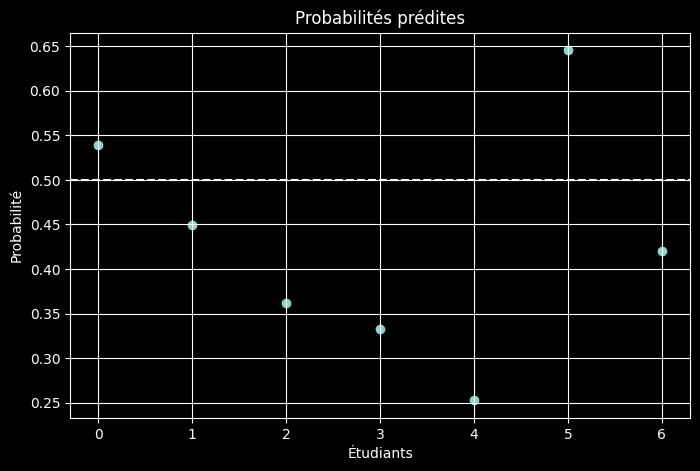

In [10]:
# ============================================================
# CELLULE 6 : VISUALISATION 1
# ============================================================

plt.figure(figsize=(8,5))
plt.scatter(range(len(probas)), probas)
plt.axhline(y=0.5, linestyle='--')
plt.title("Probabilités prédites")
plt.xlabel("Étudiants")
plt.ylabel("Probabilité")
plt.grid(True)
plt.show()

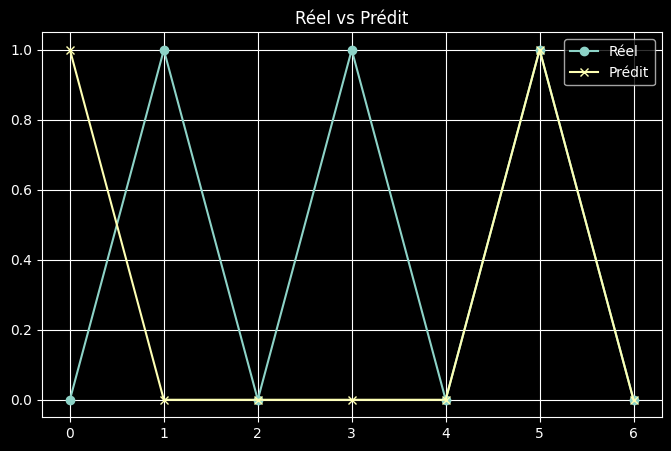

In [11]:
# ============================================================
# CELLULE 7 : VISUALISATION 2
# ============================================================

plt.figure(figsize=(8,5))
plt.plot(y, marker='o', label="Réel")
plt.plot(classes_predites, marker='x', label="Prédit")
plt.legend()
plt.title("Réel vs Prédit")
plt.grid(True)
plt.show()